In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix

# 0. Import database

In [2]:
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# importa base separando por tabulação
base = pd.read_csv(url, sep="\t", encoding="Latin-1")

# cria uma lista com os nomes das colunas
header = ['ID_CLIENTE', 'TIPO_FUNCIONARIO', 'DIA_PAGAMENTO', 'TIPO_ENVIO_APLICACAO', 'QUANT_CARTOES_ADICIONAIS',
          'TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL', 'ESTADO_NASCIMENTO',
          'CIDADE_NASCIMENTO', 'NACIONALIDADE', 'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL',
          'FLAG_TELEFONE_RESIDENCIAL', 'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'TIPO_RESIDENCIA', 'MESES_RESIDENCIA',
          'FLAG_TELEFONE_MOVEL', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD',
          'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS',
          'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'EMPRESA',
          'ESTADO_PROFISSIONAL', 'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
          'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'MESES_NO_TRABALHO', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO',
          'CODIGO_PROFISSAO_CONJUGE', 'NIVEL_EDUCACIONAL_CONJUGE', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG',
          'FLAG_CPF', 'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'FLAG_REGISTRO_ACSP', 'IDADE', 'CEP_RESIDENCIAL_3',
          'CEP_PROFISSIONAL_3', 'ROTULO_ALVO_MAU=1'
]

# adiciona nome às colunas do data frame
base.columns = header
base

C:\Users\ivan_\AppData\Local\Temp\ipykernel_46636\1059617363.py:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv(url, sep="\t", encoding="Latin-1")


,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
0,2,C,15,Carga,0,1,F,2,0,0,...,0,0,0,0,1,N,34,230,230,1
1,3,C,5,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,27,591,591,0
2,4,C,20,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,61,545,545,0
3,5,C,10,Web,0,1,M,2,0,0,...,0,0,0,0,1,N,48,235,235,1
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996,C,10,0,0,1,F,1,2,0,...,0,0,0,0,1,N,36,591,591,1
49995,49997,C,25,0,0,1,F,1,0,0,...,0,0,0,0,2,N,21,186,186,0
49996,49998,C,5,Web,0,1,M,2,3,0,...,0,0,0,0,1,N,41,715,715,0
49997,49999,C,1,Web,0,1,F,1,1,0,...,0,0,0,0,1,N,28,320,320,1


In [3]:
# descrição inicial do tipo de cada variável e qtd de valores não-nulos
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENTE                         49999 non-null  int64  
 1   TIPO_FUNCIONARIO                   49999 non-null  object 
 2   DIA_PAGAMENTO                      49999 non-null  int64  
 3   TIPO_ENVIO_APLICACAO               49999 non-null  object 
 4   QUANT_CARTOES_ADICIONAIS           49999 non-null  int64  
 5   TIPO_ENDERECO_POSTAL               49999 non-null  int64  
 6   SEXO                               49999 non-null  object 
 7   ESTADO_CIVIL                       49999 non-null  int64  
 8   QUANT_DEPENDENTES                  49999 non-null  int64  
 9   NIVEL_EDUCACIONAL                  49999 non-null  int64  
 10  ESTADO_NASCIMENTO                  49999 non-null  object 
 11  CIDADE_NASCIMENTO                  49999 non-null  obj

In [4]:
# contagem de valores nulos em cada variável
base.isnull().sum()

ID_CLIENTE                               0
TIPO_FUNCIONARIO                         0
DIA_PAGAMENTO                            0
TIPO_ENVIO_APLICACAO                     0
QUANT_CARTOES_ADICIONAIS                 0
TIPO_ENDERECO_POSTAL                     0
SEXO                                     0
ESTADO_CIVIL                             0
QUANT_DEPENDENTES                        0
NIVEL_EDUCACIONAL                        0
ESTADO_NASCIMENTO                        0
CIDADE_NASCIMENTO                        0
NACIONALIDADE                            0
ESTADO_RESIDENCIAL                       0
CIDADE_RESIDENCIAL                       0
BAIRRO_RESIDENCIAL                       0
FLAG_TELEFONE_RESIDENCIAL                0
CODIGO_AREA_TELEFONE_RESIDENCIAL         0
TIPO_RESIDENCIA                       1349
MESES_RESIDENCIA                      3777
FLAG_TELEFONE_MOVEL                      0
FLAG_EMAIL                               0
RENDA_PESSOAL_MENSAL                     0
OUTRAS_REND

# Teste 1

## 1 - Tratamentos dos dados

### 1.1 - Separação da base inicial (numéricos e categóricos)

In [5]:
# separação das variáveis em duas bases (dados numéricos e categóricos)
base_numerica = base.select_dtypes(exclude=['object'])
base_categorica = base.select_dtypes(exclude=['int64', 'float64'])

In [6]:
# apresentação da base com dados numéricos
base_numerica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_CLIENTE                        49999 non-null  int64  
 1   DIA_PAGAMENTO                     49999 non-null  int64  
 2   QUANT_CARTOES_ADICIONAIS          49999 non-null  int64  
 3   TIPO_ENDERECO_POSTAL              49999 non-null  int64  
 4   ESTADO_CIVIL                      49999 non-null  int64  
 5   QUANT_DEPENDENTES                 49999 non-null  int64  
 6   NIVEL_EDUCACIONAL                 49999 non-null  int64  
 7   NACIONALIDADE                     49999 non-null  int64  
 8   TIPO_RESIDENCIA                   48650 non-null  float64
 9   MESES_RESIDENCIA                  46222 non-null  float64
 10  FLAG_EMAIL                        49999 non-null  int64  
 11  RENDA_PESSOAL_MENSAL              49999 non-null  float64
 12  OUTR

In [7]:
# apresentação da base com dados categóricos
base_categorica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   TIPO_FUNCIONARIO                   49999 non-null  object
 1   TIPO_ENVIO_APLICACAO               49999 non-null  object
 2   SEXO                               49999 non-null  object
 3   ESTADO_NASCIMENTO                  49999 non-null  object
 4   CIDADE_NASCIMENTO                  49999 non-null  object
 5   ESTADO_RESIDENCIAL                 49999 non-null  object
 6   CIDADE_RESIDENCIAL                 49999 non-null  object
 7   BAIRRO_RESIDENCIAL                 49999 non-null  object
 8   FLAG_TELEFONE_RESIDENCIAL          49999 non-null  object
 9   CODIGO_AREA_TELEFONE_RESIDENCIAL   49999 non-null  object
 10  FLAG_TELEFONE_MOVEL                49999 non-null  object
 11  EMPRESA                            49999 non-null  object
 12  ESTA

#### 1.1.1 - Dummies: TIPO FUNCIONARIO

In [8]:
# conversão da variável 'TIPO_FUNCIONARIO' em variáveis dummies
tipo_func = pd.get_dummies(base_categorica['TIPO_FUNCIONARIO'],drop_first=True)
tipo_func.head()

""
0
1
2
3
4


#### 1.1.2 - Dummies: TIPO ENVIO APLICACAO

In [9]:
# conversão da variável 'TIPO_ENVIO_APLICACAO' em dummies
tipo_env_ap = pd.get_dummies(base_categorica['TIPO_ENVIO_APLICACAO'],drop_first=True)
tipo_env_ap.head()

,Carga,Web
0,True,False
1,False,True
2,False,True
3,False,True
4,False,False


#### 1.1.3 - Dummies: SEXO

In [10]:
# conversão da variável 'SEXO' em dummies
sexo = pd.get_dummies(base_categorica['SEXO'],drop_first=True)
sexo.head()

,F,M,N
0,True,False,False
1,True,False,False
2,True,False,False
3,False,True,False
4,False,True,False


#### 1.1.4 - Dummies: EMPRESA

In [11]:
# conversão da variável 'TIPO_ENVIO_APLICACAO' em dummies
empresa = pd.get_dummies(base_categorica['EMPRESA'],drop_first=True)
empresa.head()

,Y
0,True
1,False
2,False
3,False
4,True


### 1.2 - Concatenação dos dados numéricos e dummies

In [12]:
# concatenando a base de variáveis numéricas com as dummies das variáveis categóricas selecionadas
base_tratada = pd.concat([base_numerica, tipo_func, tipo_env_ap, sexo, empresa], axis=1)
base_tratada.head()

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,ROTULO_ALVO_MAU=1,Carga,Web,F,M,N,Y
0,2,15,0,1,2,0,0,1,1.0,1.0,...,0,1,34,1,True,False,True,False,False,True
1,3,5,0,1,2,0,0,1,1.0,NaN,...,0,1,27,0,False,True,True,False,False,False
2,4,20,0,1,2,0,0,1,NaN,NaN,...,0,1,61,0,False,True,True,False,False,False
3,5,10,0,1,2,0,0,1,1.0,12.0,...,0,1,48,1,False,True,False,True,False,False
4,6,10,0,1,2,0,0,1,1.0,4.0,...,0,2,40,1,False,False,False,True,False,True


### 1.3 - Separação da variável target

In [13]:
# separação da variável target (y)
y = base_tratada["ROTULO_ALVO_MAU=1"]

# exclusão da variável target da base de preditoras (X)
X = base_tratada.drop(columns="ROTULO_ALVO_MAU=1")

### 1.4 Inputação de dados

#### 1.4.1 - Metódo Mediana

In [14]:
# mediana
median_imputer = SimpleImputer(strategy='median')
X_median = pd.DataFrame(median_imputer.fit_transform(X), columns=X.columns)

X_median

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,Carga,Web,F,M,N,Y
0,2.0,15.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,34.0,1.0,0.0,1.0,0.0,0.0,1.0
1,3.0,5.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,6.0,...,0.0,0.0,1.0,27.0,0.0,1.0,1.0,0.0,0.0,0.0
2,4.0,20.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,6.0,...,0.0,0.0,1.0,61.0,0.0,1.0,1.0,0.0,0.0,0.0
3,5.0,10.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,12.0,...,0.0,0.0,1.0,48.0,0.0,1.0,0.0,1.0,0.0,0.0
4,6.0,10.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,4.0,...,0.0,0.0,2.0,40.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996.0,10.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,14.0,...,0.0,0.0,1.0,36.0,0.0,0.0,1.0,0.0,0.0,0.0
49995,49997.0,25.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,15.0,...,0.0,0.0,2.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0
49996,49998.0,5.0,0.0,1.0,2.0,3.0,0.0,1.0,2.0,5.0,...,0.0,0.0,1.0,41.0,0.0,1.0,0.0,1.0,0.0,1.0
49997,49999.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,6.0,...,0.0,0.0,1.0,28.0,0.0,1.0,1.0,0.0,0.0,1.0


#### 1.4.2 - Metódo Média

In [15]:
# media
mean_imputer = SimpleImputer(strategy='mean')
X_mean = pd.DataFrame(mean_imputer.fit_transform(X), columns=X.columns)

X_mean

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,Carga,Web,F,M,N,Y
0,2.0,15.0,0.0,1.0,2.0,0.0,0.0,1.0,1.00000,1.000000,...,0.0,0.0,1.0,34.0,1.0,0.0,1.0,0.0,0.0,1.0
1,3.0,5.0,0.0,1.0,2.0,0.0,0.0,1.0,1.00000,9.727035,...,0.0,0.0,1.0,27.0,0.0,1.0,1.0,0.0,0.0,0.0
2,4.0,20.0,0.0,1.0,2.0,0.0,0.0,1.0,1.25223,9.727035,...,0.0,0.0,1.0,61.0,0.0,1.0,1.0,0.0,0.0,0.0
3,5.0,10.0,0.0,1.0,2.0,0.0,0.0,1.0,1.00000,12.000000,...,0.0,0.0,1.0,48.0,0.0,1.0,0.0,1.0,0.0,0.0
4,6.0,10.0,0.0,1.0,2.0,0.0,0.0,1.0,1.00000,4.000000,...,0.0,0.0,2.0,40.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996.0,10.0,0.0,1.0,1.0,2.0,0.0,1.0,1.00000,14.000000,...,0.0,0.0,1.0,36.0,0.0,0.0,1.0,0.0,0.0,0.0
49995,49997.0,25.0,0.0,1.0,1.0,0.0,0.0,1.0,1.00000,15.000000,...,0.0,0.0,2.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0
49996,49998.0,5.0,0.0,1.0,2.0,3.0,0.0,1.0,2.00000,5.000000,...,0.0,0.0,1.0,41.0,0.0,1.0,0.0,1.0,0.0,1.0
49997,49999.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.00000,9.727035,...,0.0,0.0,1.0,28.0,0.0,1.0,1.0,0.0,0.0,1.0


#### 1.4.3 - Metódo KNN

In [16]:
# KNN Imputer
knn_imputer = KNNImputer(n_neighbors=2)
X_knn = pd.DataFrame(knn_imputer.fit_transform(X), columns=X.columns)

X_knn

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,Carga,Web,F,M,N,Y
0,2.0,15.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,34.0,1.0,0.0,1.0,0.0,0.0,1.0
1,3.0,5.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,4.0,...,0.0,0.0,1.0,27.0,0.0,1.0,1.0,0.0,0.0,0.0
2,4.0,20.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,4.0,...,0.0,0.0,1.0,61.0,0.0,1.0,1.0,0.0,0.0,0.0
3,5.0,10.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,12.0,...,0.0,0.0,1.0,48.0,0.0,1.0,0.0,1.0,0.0,0.0
4,6.0,10.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,4.0,...,0.0,0.0,2.0,40.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996.0,10.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,14.0,...,0.0,0.0,1.0,36.0,0.0,0.0,1.0,0.0,0.0,0.0
49995,49997.0,25.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,15.0,...,0.0,0.0,2.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0
49996,49998.0,5.0,0.0,1.0,2.0,3.0,0.0,1.0,2.0,5.0,...,0.0,0.0,1.0,41.0,0.0,1.0,0.0,1.0,0.0,1.0
49997,49999.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,24.5,...,0.0,0.0,1.0,28.0,0.0,1.0,1.0,0.0,0.0,1.0


#### 1.4.4 - Metódo End of Tail

In [17]:
def end_of_tail_impute(df):
    df_imputed = df.copy()
    for col in df.columns:
        mean = df[col].mean()
        std = df[col].std()
        end_tail_value = mean + 3 * std
        df_imputed[col].fillna(end_tail_value, inplace=True)
    return df_imputed

In [18]:
X_end_tail = end_of_tail_impute(X)

X_end_tail

C:\Users\ivan_\AppData\Local\Temp\ipykernel_46636\3748576062.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(end_tail_value, inplace=True)


,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,Carga,Web,F,M,N,Y
0,2,15,0,1,2,0,0,1,1.000000,1.00000,...,0,0,1,34,True,False,True,False,False,True
1,3,5,0,1,2,0,0,1,1.000000,41.73382,...,0,0,1,27,False,True,True,False,False,False
2,4,20,0,1,2,0,0,1,3.855753,41.73382,...,0,0,1,61,False,True,True,False,False,False
3,5,10,0,1,2,0,0,1,1.000000,12.00000,...,0,0,1,48,False,True,False,True,False,False
4,6,10,0,1,2,0,0,1,1.000000,4.00000,...,0,0,2,40,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996,10,0,1,1,2,0,1,1.000000,14.00000,...,0,0,1,36,False,False,True,False,False,False
49995,49997,25,0,1,1,0,0,1,1.000000,15.00000,...,0,0,2,21,False,False,True,False,False,False
49996,49998,5,0,1,2,3,0,1,2.000000,5.00000,...,0,0,1,41,False,True,False,True,False,True
49997,49999,1,0,1,1,1,0,1,1.000000,41.73382,...,0,0,1,28,False,True,True,False,False,True


#### 1.4.5 - Aplicação do método escolhido

In [19]:
# aplicação do método de inputação escolhido para rodar o modelo
X = X_end_tail

In [20]:
# verificação do método de inputação (variáveis sem valores nulos)
X.isnull().sum()

ID_CLIENTE                          0
DIA_PAGAMENTO                       0
QUANT_CARTOES_ADICIONAIS            0
TIPO_ENDERECO_POSTAL                0
ESTADO_CIVIL                        0
QUANT_DEPENDENTES                   0
NIVEL_EDUCACIONAL                   0
NACIONALIDADE                       0
TIPO_RESIDENCIA                     0
MESES_RESIDENCIA                    0
FLAG_EMAIL                          0
RENDA_PESSOAL_MENSAL                0
OUTRAS_RENDAS                       0
FLAG_VISA                           0
FLAG_MASTERCARD                     0
FLAG_DINERS                         0
FLAG_AMERICAN_EXPRESS               0
FLAG_OUTROS_CARTOES                 0
QUANT_CONTAS_BANCARIAS              0
QUANT_CONTAS_BANCARIAS_ESPECIAIS    0
VALOR_PATRIMONIO_PESSOAL            0
QUANT_CARROS                        0
MESES_NO_TRABALHO                   0
CODIGO_PROFISSAO                    0
TIPO_OCUPACAO                       0
CODIGO_PROFISSAO_CONJUGE            0
NIVEL_EDUCAC

## 2 - Execução do modelo

### 2.1 - Divisão das bases de treino e teste

In [21]:
# divisão das bases (70% treino e 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 2.2 - Aplicação: Regressão Logística

In [22]:
# aplicação do método de regressão logística

from sklearn.linear_model import LogisticRegression

# inicialização do modelo usando parâmetros default
logreg = LogisticRegression(random_state=16)

# treino do modelo com os dados de estudo
logreg.fit(X_train, y_train)

# teste do modelo com os dados de estudo
y_pred = logreg.predict(X_test)

c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2.3 - Métricas de avaliação

c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

              precision    recall  f1-score   support

           0       0.74      1.00      0.85     11132
           1       0.00      0.00      0.00      3868

    accuracy                           0.74     15000
   macro avg       0.37      0.50      0.43     15000
weighted avg       0.55      0.74      0.63     15000

0.7421333333333333


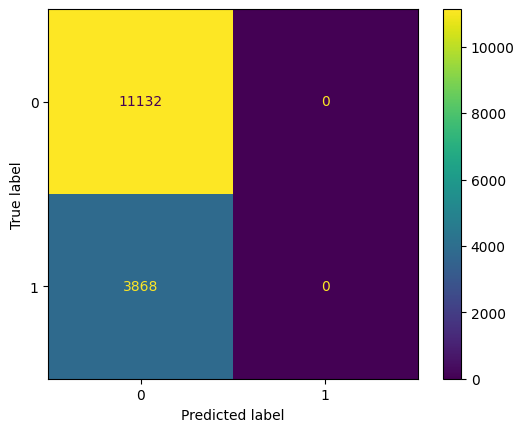

In [24]:
# geração das métricas de avaliação

cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix( y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()